# Problem 3 - Stable Softmax and Cross-Entropy

## Interview question

Implement a numerically stable softmax and cross-entropy loss for multi-class classification. Inputs are `logits: [N, C]` and integer labels `y: [N]`.

## What is being asked

You need to compute probabilities and loss without numerical overflow. You should also know the gradient of softmax cross-entropy.

## Clarifying questions

- Are labels integer class IDs or one-hot vectors?
- Should I return per-example losses or the mean loss?
- Should I implement the gradient too?


## Solution

In [ ]:
import numpy as np

"""
Softmax
    Inputs: logits (N, C)
    Outputs: probabilities (N,C)

    Softmax(Z) = exp(Z_i)/sum_{i}^{C} exp(Z_i)

Categorical Cross Entropy
    Inputs logits (N, C), Y (N, C)
    Outputs  loss

    S = softmax(logits)
    CCE (logits, Y) = - sum_{i=1}^{N}sum_{j=1}^{C} Y_j * log(S_ij) 

    log_prob = log(softmax) = log(nominator) - log(denom) = z - log(sum(z))

"""

def softmax(logits):
    """
    logits: [N, C]
    returns probabilities: [N, C]
    """
    z = logits - np.max(logits, axis=1, keepdims=True) # fixes big logit values
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def cross_entropy_loss(logits, y):
    """
    logits: [N, C]
    y: [N] integer class labels
    """
    z = logits - np.max(logits, axis=1, keepdims=True) # fixes big logit values
    log_probs = z - np.log(np.sum(np.exp(z), axis=1, keepdims=True)) # super small negative values can cause inf loss, fix that
    # log on each value is causing numerical issues, log on the sum would be better
    return -np.mean(log_probs[np.arange(logits.shape[0]), y])


def softmax_cross_entropy_grad(logits, y):
    """
    Returns dL/dlogits for mean cross-entropy.
    """
    N = logits.shape[0]
    probs = softmax(logits)
    probs[np.arange(N), y] -= 1.0
    return probs / N


# Tiny test
logits = np.array([[2000.0, 1990.0, 2100.0], [0.0, 0.01, -0.10000]])
y = np.array([0, 2])
print(softmax(logits))
print(cross_entropy_loss(logits, y))
print(softmax_cross_entropy_grad(logits, y))

[[3.72007598e-44 1.68891188e-48 1.00000000e+00]
 [3.43066403e-01 3.46514278e-01 3.10419319e-01]]
50.58491562738879
[[-5.00000000e-01  8.44455940e-49  5.00000000e-01]
 [ 1.71533202e-01  1.73257139e-01 -3.44790341e-01]]


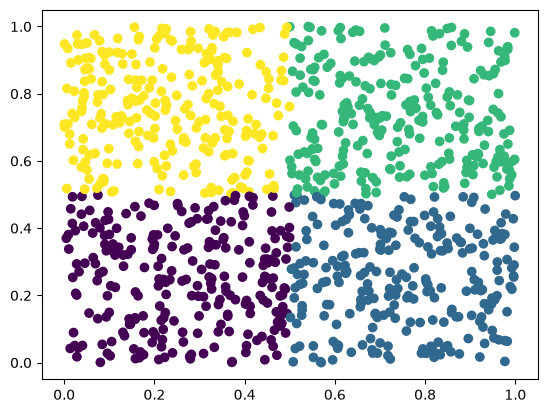

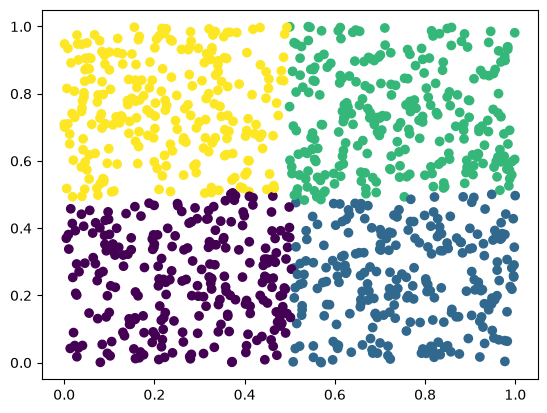

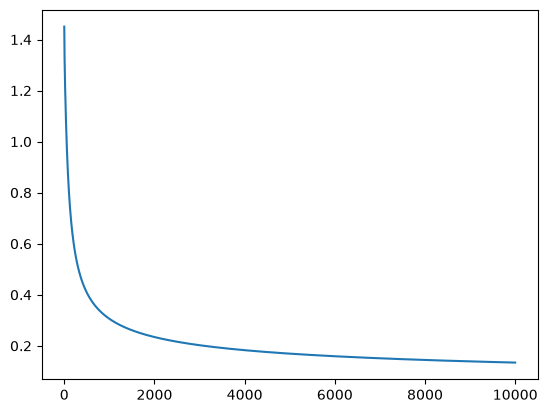

In [52]:
import numpy as np
import torch as th
import matplotlib.pyplot as plt

"""

"""

def multi_logistic_regression_fit(X: np.ndarray, Y: np.ndarray, lr: float = 0.4, steps: int = 10000):
    N, D = X.shape[0], X.shape[1]
    C = Y.shape[1]

    W = np.random.rand(D, C)
    b = np.random.rand(C)

    losses = []
    for _ in range(steps):
        Z = X @ W + b # logits
        Y_p = softmax(Z)

        loss = cross_entropy_loss(Z, np.argmax(Y, 1))
        losses.append(loss)

        g_w = X.T @ (Y_p - Y) / N
        g_b = (Y_p - Y).mean(0)

        W -= lr*g_w
        b -= lr*g_b

    return W, b, losses


def pred(W, b, X):
    probs = softmax(X @ W + b)
    preds = np.argmax(probs, 1)
    return preds
                    

if __name__ == "__main__":
    N = 1000
    D = 2
    C = 4
    X = np.random.rand(N, D)
    
    Y = np.zeros((N, C)).astype(np.float16)
    Y[(X[:, 0]<0.5) & (X[:, 1]<0.5)] = [1, 0, 0, 0]
    Y[(X[:, 0]>0.5) & (X[:, 1]<0.5)] = [0, 1, 0, 0]
    Y[(X[:, 0]>0.5) & (X[:, 1]>0.5)] = [0, 0, 1, 0]
    Y[(X[:, 0]<0.5) & (X[:, 1]>0.5)] = [0, 0, 0, 1]
    

    plt.scatter(X[:, 0], X[:, 1], c=np.argmax(Y, 1))
    plt.show()
    
    W, b, losses = multi_logistic_regression_fit(X, Y)

    Y_p = pred(W, b, X)

    plt.scatter(X[:, 0], X[:, 1], c=Y_p)
    plt.show()

    plt.plot(np.arange(len(losses)), losses)
    plt.show()